In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
url = "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/classification_sprint/cc_approvals.data"

column_names = [
    "Gender",
    "Age",
    "Debt",
    "Married",
    "BankCustomer",
    "EducationLevel",
    "Ethnicity",
    "YearsEmployed",
    "PriorDefault",
    "Employed",
    "CreditScore",
    "DriversLicense",
    "Citizen",
    "ZipCode",
    "Income",
    "ApprovalStatus"
]

data = pd.read_csv(
    url,
    header=None,
    names=column_names
)

data.head()

,Gender,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,ApprovalStatus
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


In [3]:
data.shape

(690, 16)

In [4]:

data.columns

Index(['Gender', 'Age', 'Debt', 'Married', 'BankCustomer', 'EducationLevel',
       'Ethnicity', 'YearsEmployed', 'PriorDefault', 'Employed', 'CreditScore',
       'DriversLicense', 'Citizen', 'ZipCode', 'Income', 'ApprovalStatus'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          690 non-null    object 
 1   Age             690 non-null    object 
 2   Debt            690 non-null    float64
 3   Married         690 non-null    object 
 4   BankCustomer    690 non-null    object 
 5   EducationLevel  690 non-null    object 
 6   Ethnicity       690 non-null    object 
 7   YearsEmployed   690 non-null    float64
 8   PriorDefault    690 non-null    object 
 9   Employed        690 non-null    object 
 10  CreditScore     690 non-null    int64  
 11  DriversLicense  690 non-null    object 
 12  Citizen         690 non-null    object 
 13  ZipCode         690 non-null    object 
 14  Income          690 non-null    int64  
 15  ApprovalStatus  690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


In [6]:
data = data.replace("?", np.nan)
data.head()

,Gender,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,ApprovalStatus
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


In [7]:
null_values = data.isnull().sum()
null_values

,0
Gender,12
Age,12
Debt,0
Married,6
BankCustomer,6
EducationLevel,9
Ethnicity,9
YearsEmployed,0
PriorDefault,0
Employed,0


In [8]:
numeric_columns = [
    "Age",
    "Debt",
    "YearsEmployed",
    "CreditScore",
    "ZipCode",
    "Income"
]

data[numeric_columns] = data[numeric_columns].apply(
    pd.to_numeric
)

data[numeric_columns] = data[numeric_columns].fillna(
    data[numeric_columns].median()
)

categorical_columns = data.select_dtypes(include="object").columns

data[categorical_columns] = data[categorical_columns].fillna(
    data[categorical_columns].mode().iloc[0]
)

data.isnull().sum()

,0
Gender,0
Age,0
Debt,0
Married,0
BankCustomer,0
EducationLevel,0
Ethnicity,0
YearsEmployed,0
PriorDefault,0
Employed,0


In [9]:
duplicate_count = data.duplicated().sum()
duplicate_count

np.int64(0)

In [10]:
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

In [11]:
encoder = LabelEncoder()
categorical_columns = data.select_dtypes(include="object").columns
data[categorical_columns] = data[categorical_columns].apply(
    encoder.fit_transform
)
data.head()

,Gender,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,ApprovalStatus
0,1,30.83,0.000,1,0,12,7,1.25,1,1,1,0,0,202.0,0,0
1,0,58.67,4.460,1,0,10,3,3.04,1,1,6,0,0,43.0,560,0
2,0,24.50,0.500,1,0,10,3,1.50,1,0,0,0,0,280.0,824,0
3,1,27.83,1.540,1,0,12,7,3.75,1,1,5,1,0,100.0,3,0
4,1,20.17,5.625,1,0,12,7,1.71,1,0,0,0,2,120.0,0,0


In [12]:
data.describe()

,Gender,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,ApprovalStatus
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000,690.000000
mean,0.695652,31.514116,4.758725,1.233333,0.475362,5.698551,5.098551,2.223406,0.523188,0.427536,2.40000,0.457971,0.176812,183.562319,1017.385507,0.555072
std,0.460464,11.860245,4.978163,0.430063,0.850238,4.285748,2.510731,3.346513,0.499824,0.495080,4.86294,0.498592,0.557869,172.190278,5210.102598,0.497318
min,0.000000,13.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,22.670000,1.000000,1.000000,0.000000,1.000000,3.000000,0.165000,0.000000,0.000000,0.00000,0.000000,0.000000,80.000000,0.000000,0.000000
50%,1.000000,28.460000,2.750000,1.000000,0.000000,5.000000,7.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,160.000000,5.000000,1.000000
75%,1.000000,37.707500,7.207500,1.000000,0.000000,10.000000,7.000000,2.625000,1.000000,1.000000,3.00000,1.000000,0.000000,272.000000,395.500000,1.000000
max,1.000000,80.250000,28.000000,2.000000,2.000000,13.000000,8.000000,28.500000,1.000000,1.000000,67.00000,1.000000,2.000000,2000.000000,100000.000000,1.000000


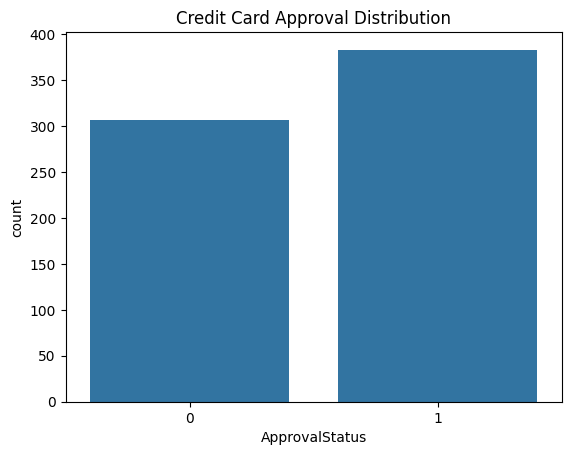

In [13]:
sns.countplot(x="ApprovalStatus", data=data)
plt.title("Credit Card Approval Distribution")
plt.show()

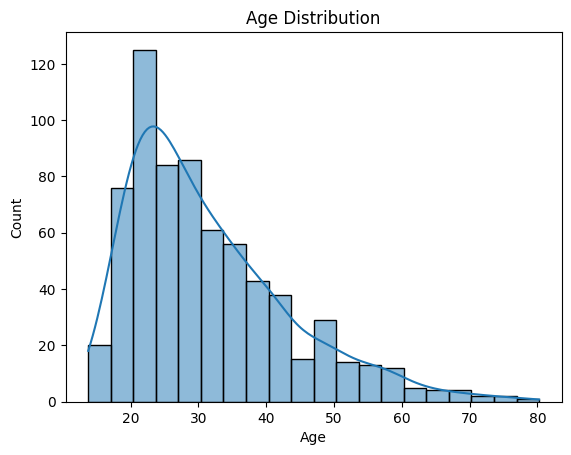

In [14]:
sns.histplot(data["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

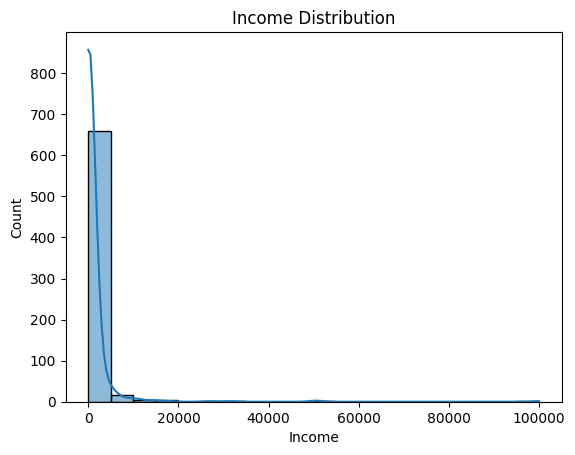

In [15]:
sns.histplot(data["Income"], bins=20, kde=True)
plt.title("Income Distribution")
plt.show()

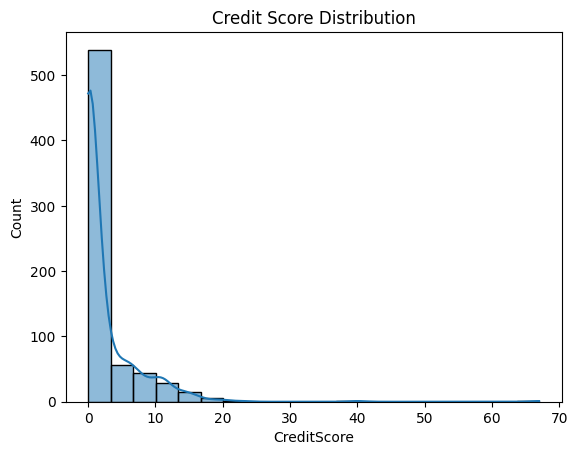

In [16]:
sns.histplot(data["CreditScore"], bins=20, kde=True)
plt.title("Credit Score Distribution")
plt.show()

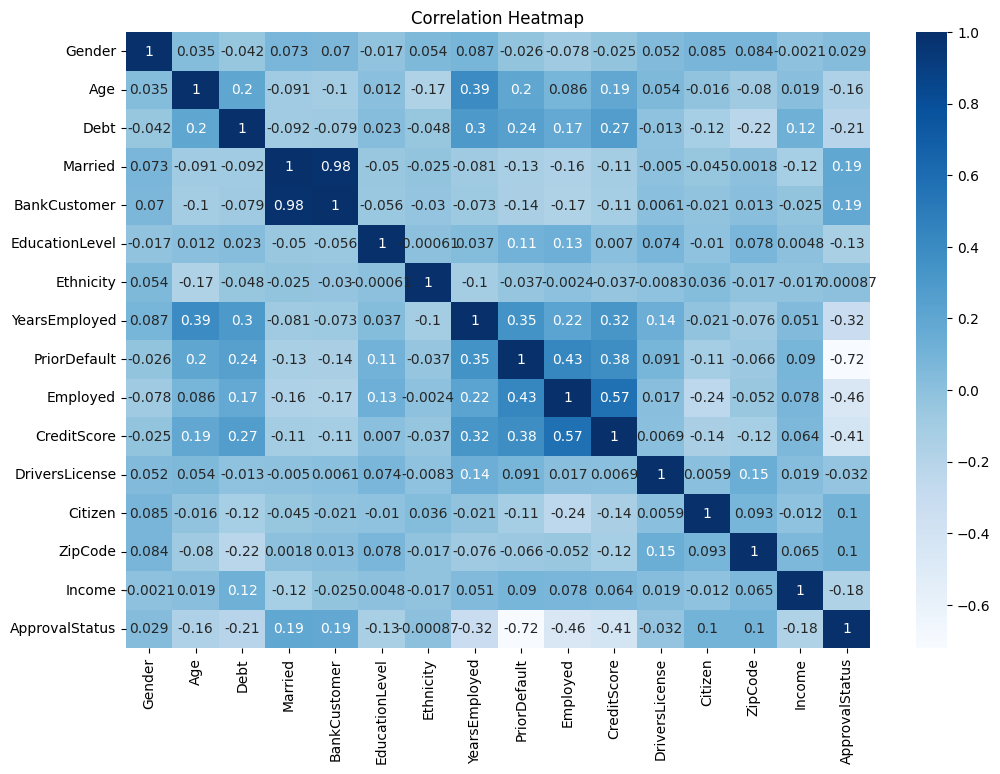

In [17]:
correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues"
)
plt.title("Correlation Heatmap")
plt.show()

In [18]:
X = data.drop(columns=["ApprovalStatus"])
y = data["ApprovalStatus"]
X.head()

,Gender,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income
0,1,30.83,0.000,1,0,12,7,1.25,1,1,1,0,0,202.0,0
1,0,58.67,4.460,1,0,10,3,3.04,1,1,6,0,0,43.0,560
2,0,24.50,0.500,1,0,10,3,1.50,1,0,0,0,0,280.0,824
3,1,27.83,1.540,1,0,12,7,3.75,1,1,5,1,0,100.0,3
4,1,20.17,5.625,1,0,12,7,1.71,1,0,0,0,2,120.0,0


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
X_train.shape

(552, 15)

In [20]:
model = LogisticRegression(max_iter=1000)
model

LogisticRegression(max_iter=1000)

In [21]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [22]:
y_pred = model.predict(X_test)
y_pred[:10]

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 1])

In [23]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8333333333333334

In [24]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[58, 12],
       [11, 57]])

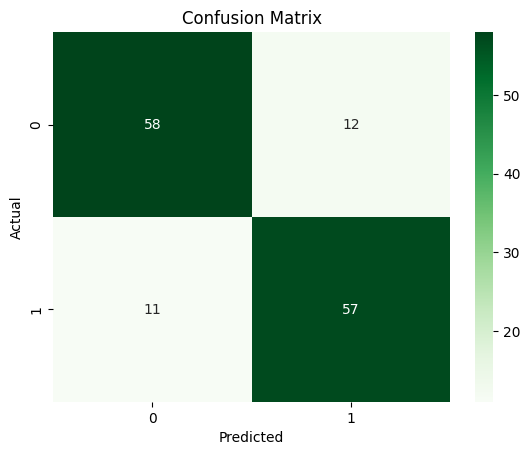

In [25]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
report = classification_report(
    y_test,
    y_pred
)
report

'              precision    recall  f1-score   support\n\n           0       0.84      0.83      0.83        70\n           1       0.83      0.84      0.83        68\n\n    accuracy                           0.83       138\n   macro avg       0.83      0.83      0.83       138\nweighted avg       0.83      0.83      0.83       138\n'

In [27]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]})
coefficients

,Feature,Coefficient
0,Gender,0.211113
1,Age,-0.003749
2,Debt,0.035574
3,Married,1.299812
4,BankCustomer,-0.265697
5,EducationLevel,-0.028805
6,Ethnicity,-0.059271
7,YearsEmployed,-0.108559
8,PriorDefault,-3.298517
9,Employed,-0.433353
